In [16]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [18]:
UCMERCED_PATH = "../dataset/UCMerced"

In [19]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [20]:
dataset = ImageFolder(
    root=UCMERCED_PATH,
    transform=test_transform
)

classes = dataset.classes

print("Total Images :", len(dataset))
print("Total Classes:", len(classes))

Total Images : 2100
Total Classes: 21


In [21]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

In [22]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [23]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    21
)

model.load_state_dict(
    torch.load("../models/resnet18_ucmerced_final.pth")
)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [24]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(preds.cpu().numpy())

In [25]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 96.19%


In [26]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Macro F1  : {f1:.4f}")

Precision : 0.9638
Recall    : 0.9626
Macro F1  : 0.9610


In [27]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes
)

print(report)



                   precision    recall  f1-score   support

     agricultural       1.00      1.00      1.00        22
         airplane       1.00      1.00      1.00        14
  baseballdiamond       1.00      0.94      0.97        18
            beach       1.00      1.00      1.00        23
        buildings       0.75      1.00      0.86        15
        chaparral       1.00      1.00      1.00        20
 denseresidential       0.92      0.75      0.83        16
           forest       1.00      1.00      1.00        22
          freeway       1.00      1.00      1.00        22
       golfcourse       0.95      0.86      0.90        22
           harbor       1.00      1.00      1.00        17
     intersection       0.88      1.00      0.93        21
mediumresidential       0.88      0.92      0.90        25
   mobilehomepark       1.00      1.00      1.00        21
         overpass       1.00      1.00      1.00        18
       parkinglot       1.00      1.00      1.00       

C:\Users\Anildas\AppData\Local\Temp\ipykernel_37792\1419327276.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette="viridis")


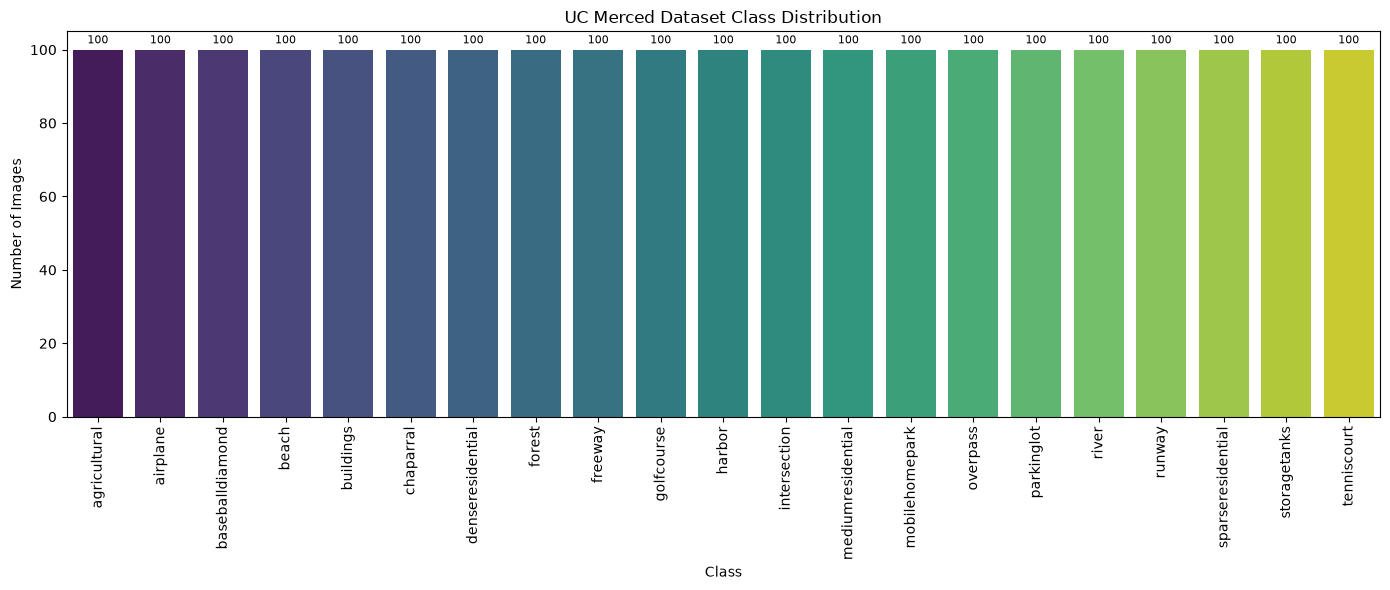

In [28]:
labels = np.array(dataset.targets)
counts = np.bincount(labels, minlength=len(classes))

plt.figure(figsize=(14, 6))
sns.barplot(x=classes, y=counts, palette="viridis")

plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("UC Merced Dataset Class Distribution")

for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [29]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 17  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  2  0 12  0  0  0  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  3  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0  1 23  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0]
 [ 0  0  0

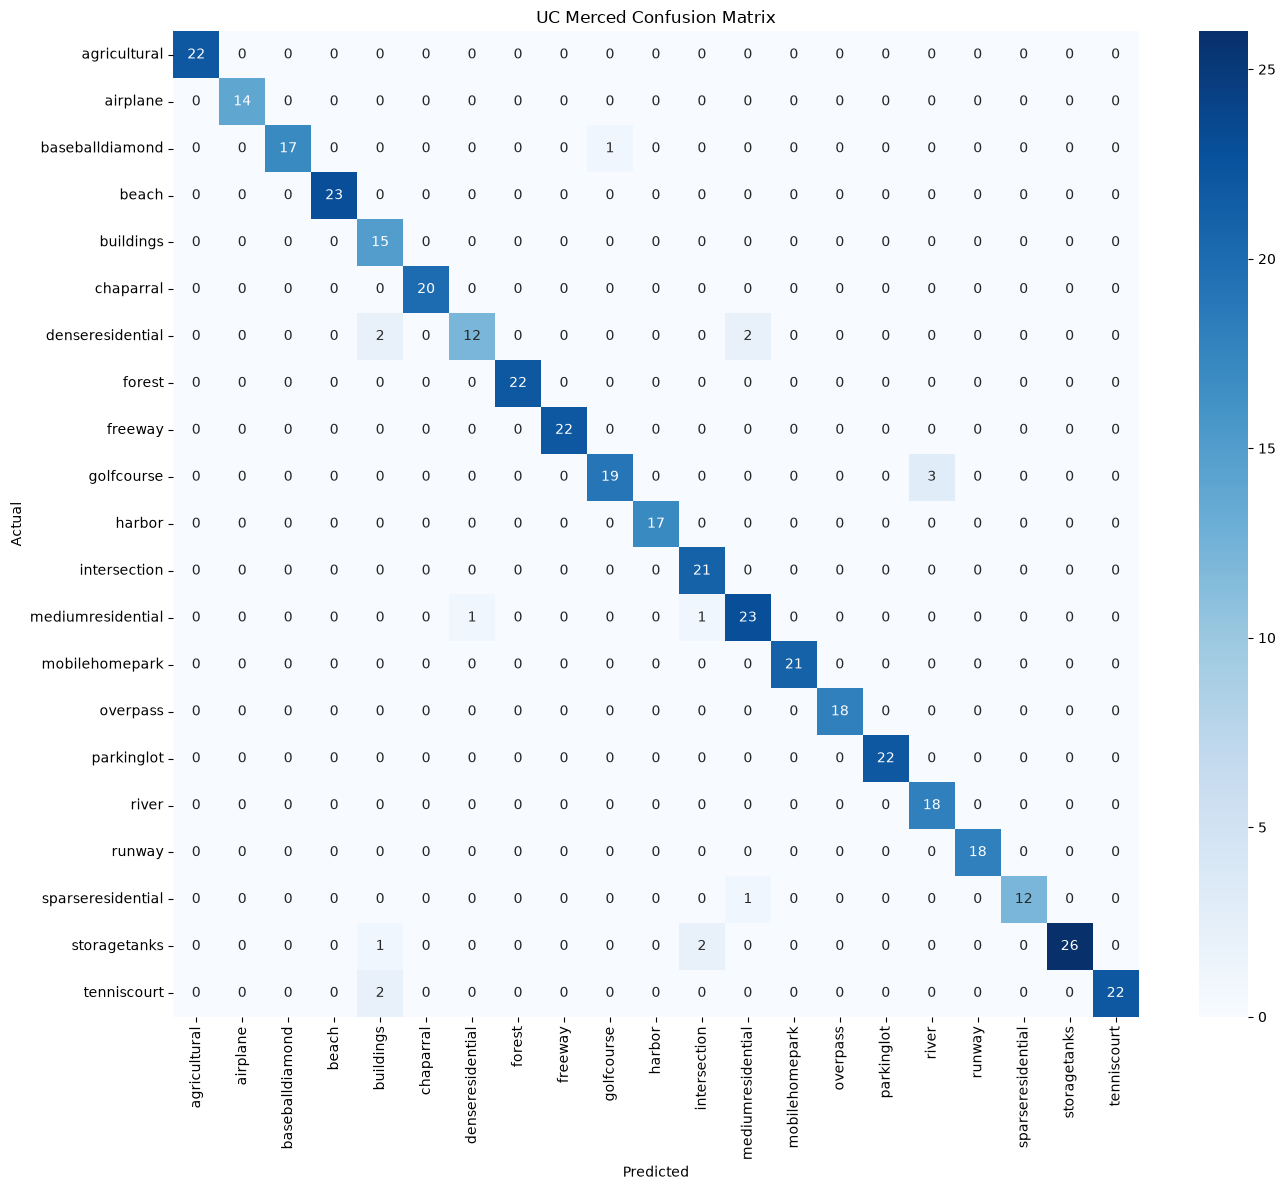

In [30]:
plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UC Merced Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

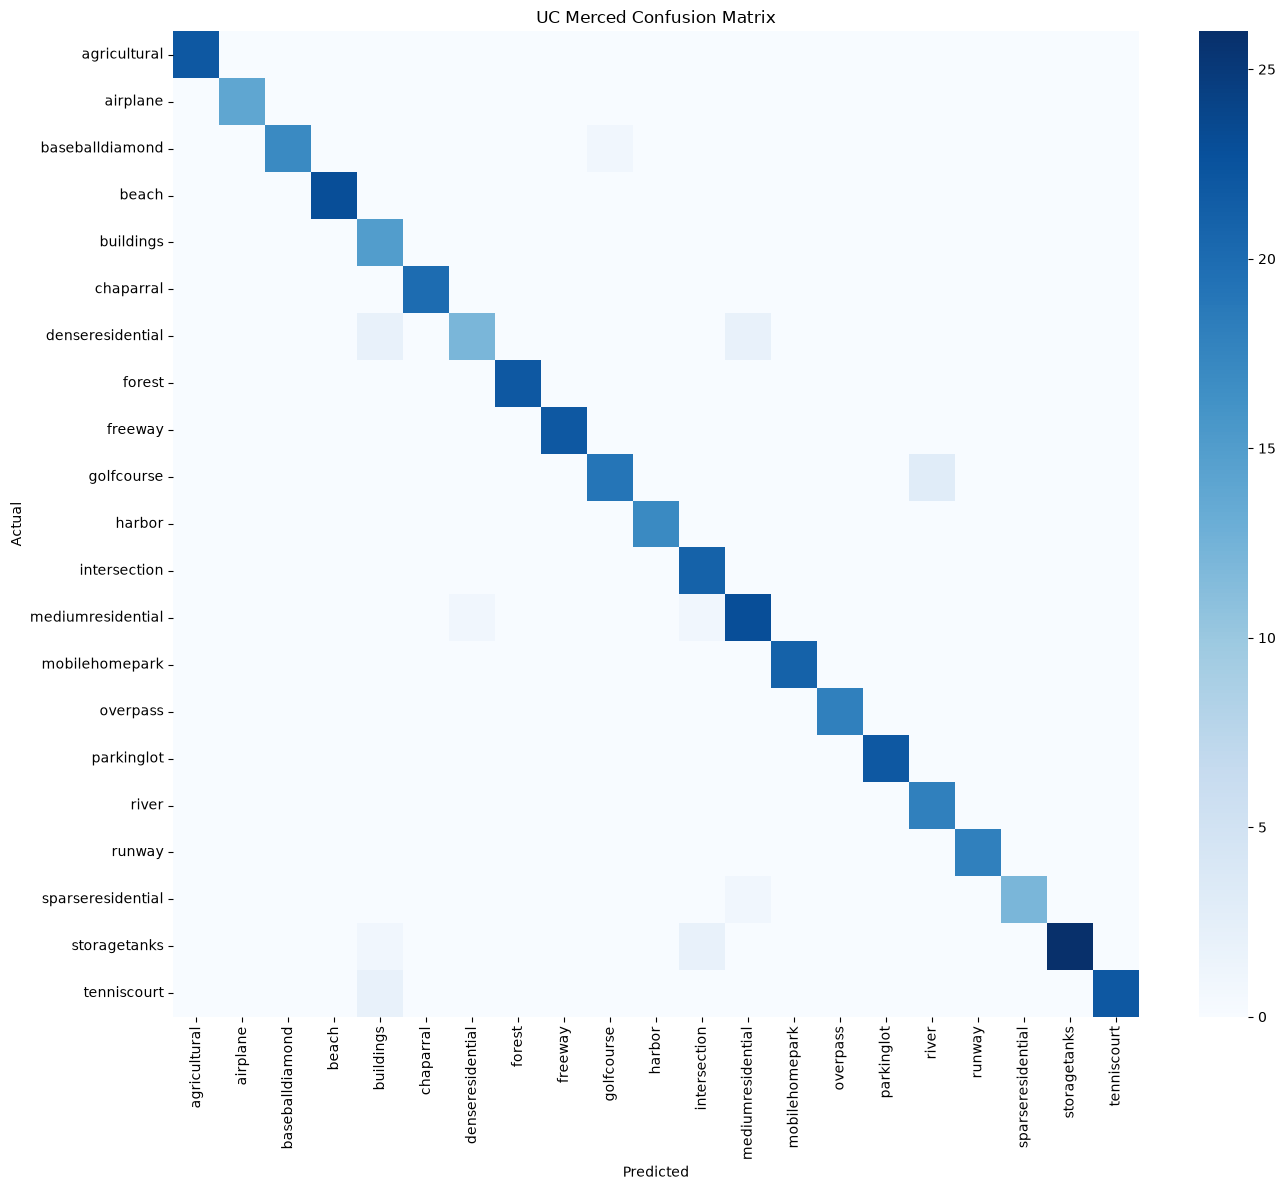

In [31]:
plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UC Merced Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/ucmerced_confusion_matrix.png",
    dpi=300
)

plt.show()

In [32]:
class_names = dataset.classes

images, labels = next(iter(val_loader))

images = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

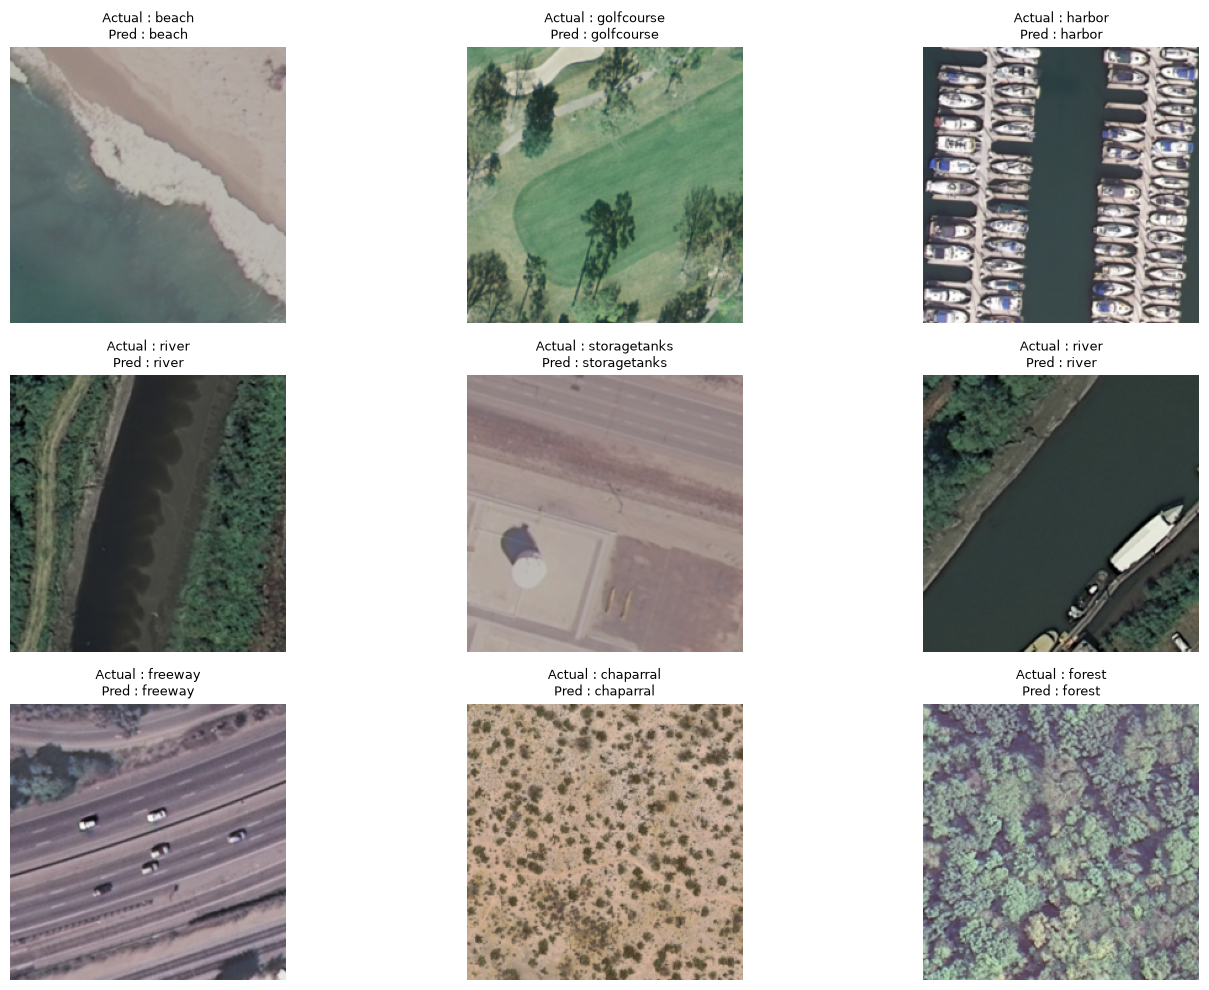

In [33]:
plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = images[i].permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img = np.clip(img,0,1)

    plt.imshow(img)

    plt.title(
        f"Actual : {class_names[labels[i]]}\nPred : {class_names[preds[i]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
with open("../outputs/ucmerced_metrics.txt","w") as f:

    f.write(f"Accuracy : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall : {recall:.4f}\n")
    f.write(f"Macro F1 : {f1:.4f}\n\n")

    f.write(report)

print("Evaluation report saved successfully!")

Evaluation report saved successfully!
